In [20]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv


In [21]:
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [22]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    score: float

In [23]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title from state
    title = state['title']

    # call llm for gen outline
    prompt = f"Create a detailed outline for a blog post with the title: {title}"
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [24]:
def create_blog(state: BlogState) -> BlogState:

    # fetch title and outline from state
    title = state['title']
    outline = state['outline']

    # call llm for gen blog content
    prompt = f"Write a detailed blog post with the title: {title} and the following outline: \n{outline}"
    content = model.invoke(prompt).content

    # update state
    state['content'] = content

    return state

In [25]:
def rate_blog(state: BlogState) -> BlogState:

    content = state['content']

    prompt = f"""
    Rate the following blog on a scale of 1 to 10.

    Return ONLY the numeric score.
    Do not give any explanation.

    Blog:
    {content}
    """

    score = float(model.invoke(prompt).content.strip())

    state['score'] = score

    return state

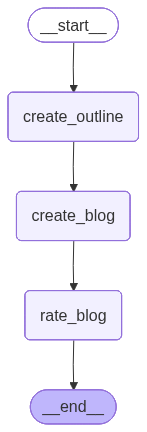

In [ ]:
graph = StateGraph(BlogState)

#add nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('rate_blog',rate_blog)

#add edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'rate_blog')
graph.add_edge('rate_blog', END)

workflow = graph.compile()

In [27]:
initial_state = {'title' : 'Rise of AI in India'}

final_state = workflow.invoke(initial_state)
print(final_state['content'])
print(final_state['score'])

## Rise of AI in India: A New Era of Innovation and Transformation

---

**I. Introduction: The AI Wave Reaches Indian Shores**

The global technological landscape is in the midst of a profound transformation, spearheaded by the relentless march of Artificial Intelligence. From powering personalized recommendations to revolutionizing scientific discovery, AI is no longer a futuristic concept but a present-day reality reshaping industries and societies worldwide. As this monumental AI wave sweeps across the globe, its impact is nowhere more keenly felt than in India – a nation uniquely positioned as a burgeoning tech hub, armed with a massive talent pool, and boasting a vast market ripe for digital transformation.

In this dynamic environment, AI is rapidly emerging as a pivotal force in India, driving unprecedented innovation, economic growth, and societal change. It presents a unique blend of challenges and opportunities, charting a course towards a truly "AI-powered India." This blog